<a href="https://colab.research.google.com/github/shreedharp-18/shreedharp-18/blob/main/end_to_end_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
df.shape

(100, 3)

In [ ]:
import matplotlib.pyplot as plt

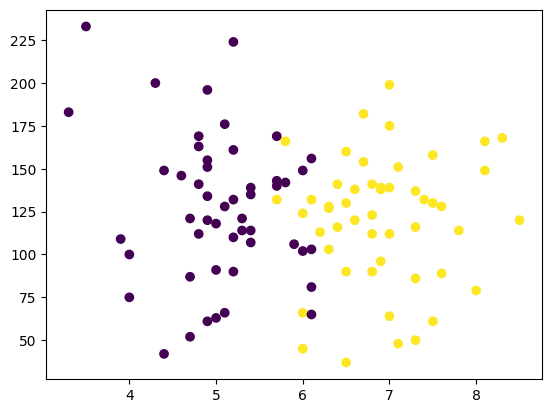

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.1)

In [ ]:
X_train

,cgpa,iq
35,6.8,90.0
73,4.9,61.0
56,6.1,65.0
4,5.8,142.0
74,6.7,154.0
...,...,...
88,4.4,149.0
33,6.0,149.0
24,4.7,121.0
12,5.4,139.0


In [ ]:
Y_train

,placement
35,1
73,0
56,0
4,0
74,1
...,...
88,0
33,0
24,0
12,0


In [ ]:
X_test

,cgpa,iq
17,3.3,183.0
67,5.0,118.0
57,6.5,130.0
75,4.8,169.0
40,4.9,134.0
7,5.0,63.0
68,4.0,75.0
71,6.1,132.0
79,6.5,90.0
26,7.0,199.0


In [ ]:
Y_test

,placement
17,0
67,0
57,1
75,0
40,0
7,0
68,0
71,1
79,1
26,1


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

In [ ]:
X_train

array([[ 6.58434786e-01, -8.37598527e-01],
       [-1.04750989e+00, -1.57491123e+00],
       [ 2.99288539e-02, -1.47321292e+00],
       [-2.39430831e-01,  4.84479418e-01],
       [ 5.68648224e-01,  7.89574328e-01],
       [ 1.37672728e+00,  1.28535356e-01],
       [ 6.58434786e-01,  4.59054842e-01],
       [ 7.48221347e-01,  3.82781114e-01],
       [ 1.55630040e+00, -2.27408706e-01],
       [ 5.68648224e-01,  1.50146245e+00],
       [ 1.10736759e+00, -9.39296831e-01],
       [ 2.99288539e-02,  8.40423480e-01],
       [ 2.99288539e-02, -5.07079041e-01],
       [-8.67936763e-01,  1.34891500e+00],
       [-1.04750989e+00,  1.85740651e+00],
       [-1.22708301e+00, -9.13872255e-01],
       [ 1.10736759e+00,  3.57356539e-01],
       [-6.88363639e-01, -4.94366753e-02],
       [-7.78150201e-01, -3.29107010e-01],
       [ 2.99288539e-01,  4.59054842e-01],
       [-3.29217393e-01,  5.09903994e-01],
       [-1.13729645e+00,  1.01839551e+00],
       [-5.98577078e-01, -4.05380737e-01],
       [ 6.

In [ ]:
X_test = scaler.transform(X_test)

In [ ]:
X_test

array([[-2.48409487,  1.52688703],
       [-0.95772332, -0.1257104 ],
       [ 0.3890751 ,  0.17938451],
       [-1.13729645,  1.17094297],
       [-1.04750989,  0.28108281],
       [-0.95772332, -1.52406208],
       [-1.85558894, -1.21896717],
       [ 0.02992885,  0.23023366],
       [ 0.3890751 , -0.83759853],
       [ 0.83800791,  1.93368024]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
clf = clf.fit(X_train, Y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 1, 1])

In [ ]:
Y_test

,placement
17,0
67,0
57,1
75,0
40,0
7,0
68,0
71,1
79,1
26,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_test, y_pred)

1.0

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

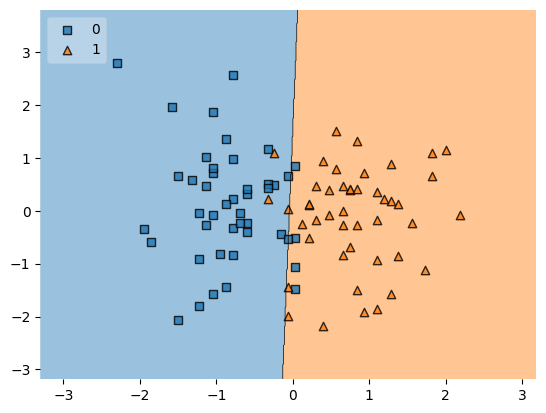

In [ ]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf, open('model.pkl', 'wb'))